In [ ]:
import os
import cv2
import gc
import json
import numpy as np
import pandas as pd
import itertools
from tqdm.autonotebook import tqdm
import albumentations as A
import matplotlib.pyplot as plt

import torch
from torch import nn
import torch.nn.functional as F
import timm
from transformers import DistilBertModel, DistilBertConfig, DistilBertTokenizer

<ipython-input-1-aaa55f4caea2>:8: TqdmExperimentalWarning: Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)
  from tqdm.autonotebook import tqdm
/usr/local/lib/python3.11/dist-packages/albumentations/__init__.py:24: UserWarning: A new version of Albumentations is available: 2.0.1 (you have 1.4.20). Upgrade using: pip install -U albumentations. To disable automatic update checks, set the environment variable NO_ALBUMENTATIONS_UPDATE to 1.
  check_for_updates()


In [ ]:
# Load model directly
from transformers import AutoTokenizer, AutoModelForPreTraining

In [ ]:
# Step 1: Mount Google Drive to access the dataset.
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [20]:
import os
import json
import cv2
import torch
import numpy as np
import pandas as pd
import albumentations as A
import torch.nn as nn
import torch.nn.functional as F
import timm
import itertools
from tqdm import tqdm
from transformers import AutoTokenizer, AutoModel, AutoConfig
import matplotlib.pyplot as plt

# Add get_lr function
def get_lr(optimizer):
    for param_group in optimizer.param_groups:
        return param_group['lr']

class CFG:
    debug = False
    # Dataset paths
    image_path1 = '/content/drive/MyDrive/Bangla Image dataset with caption/Flickr8k_Dataset/Flicker8k_Dataset'
    captions_path1 = '/content/drive/MyDrive/Bangla Image dataset with caption/Flickr8k_Dataset'
    image_path2 = '/content/drive/MyDrive/Bangla Image dataset with caption/BNATURE/Pictures'
    captions_path2 = '/content/drive/MyDrive/Bangla Image dataset with caption/BNATURE/caption/captions.json'
    image_path3 = '/content/drive/MyDrive/Bangla Image dataset with caption/Bangla Lekha 2.0/images'
    captions_path3 = '/content/drive/MyDrive/Bangla Image dataset with caption/Bangla Lekha 2.0/captions.json'

    # Training parameters
    batch_size = 32  # Reduced batch size
    gradient_accumulation_steps = 4  # Increased accumulation steps
    num_workers = 2
    pin_memory = True
    # Mixed precision settings
    mixed_precision = True

    # Model settings

    attention_dropout_prob = 0.1

    # Optimizer settings
    weight_decay = 0.01
    max_grad_norm = 1.0

    # Learning rates
    image_encoder_lr = 1e-5
    text_encoder_lr = 1e-5
    head_lr = 1e-4
    prefetch_factor = 2
    patience = 1
    hidden_dropout_prob=0.1
    factor = 0.8
    epochs = 2
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    # Model parameters
    model_name = 'resnet50'
    image_embedding = 2048
    text_encoder_model = "csebuetnlp/banglabert"
    text_embedding = 768
    text_tokenizer = "csebuetnlp/banglabert"
    max_length = 200
    pretrained = True
    trainable = True
    temperature = 1.0
    size = 224
    num_projection_layers = 1
    projection_dim = 256
    dropout = 0.1


Dataset: Flickr8k
Total Entries: 40455
Image Count: 8091
Sample Captions:
  - {'caption_id': '1000268201_693b08cb0e.jpg#0', 'english_caption': 'A child in a pink dress is climbing up a set of stairs in an entry way .', 'bengali_caption': 'একটি গোলাপী জামা পরা বাচ্চা মেয়ে একটি বাড়ির প্রবেশ পথের সিঁড়ি বেয়ে উঠছে।'}
  - {'caption_id': '1000268201_693b08cb0e.jpg#1', 'english_caption': 'A girl going into a wooden building .', 'bengali_caption': 'একটি মেয়ে শিশু একটি কাঠের বাড়িতে ঢুকছে'}
  - {'caption_id': '1000268201_693b08cb0e.jpg#2', 'english_caption': 'A little girl climbing into a wooden playhouse .', 'bengali_caption': 'একটি বাচ্চা তার কাঠের খেলাঘরে উঠছে ।'}




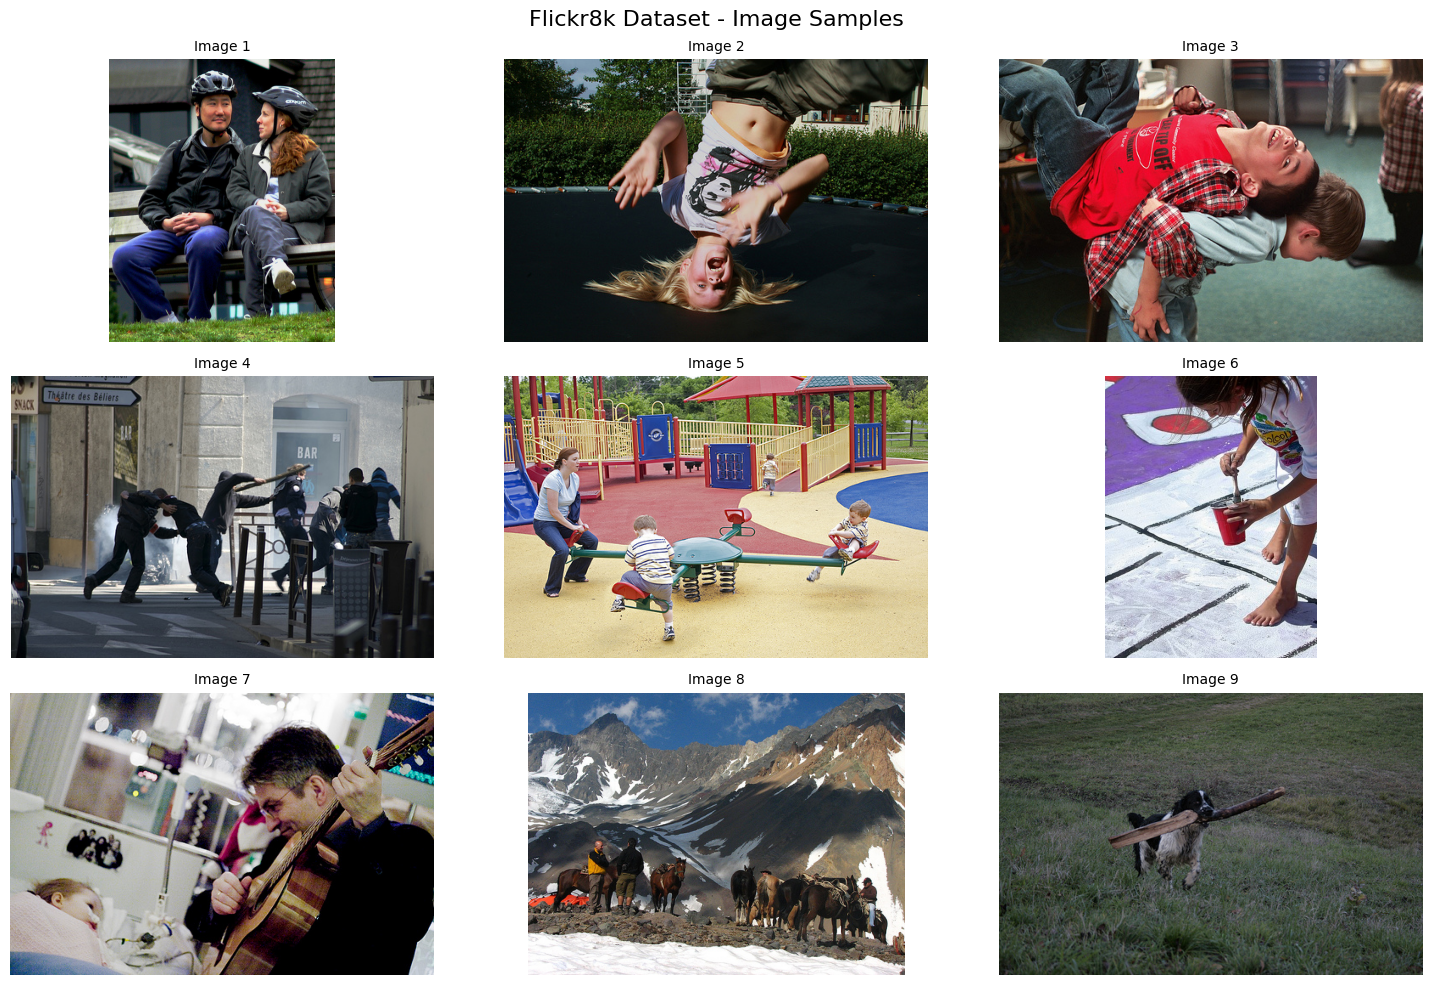

Dataset: BNATURE
Total Entries: 39105
Image Count: 8000
Sample Captions:
  - {'caption_id': '1.jpg', 'bengali_caption': '  গ্রামে হাঁটা দুই শিশু।'}
  - {'caption_id': '1.jpg', 'bengali_caption': '  দুই শিশু গ্রামে হাঁটছে।'}
  - {'caption_id': '1.jpg', 'bengali_caption': '  একটা নীল জামা পড়া শিশু।'}




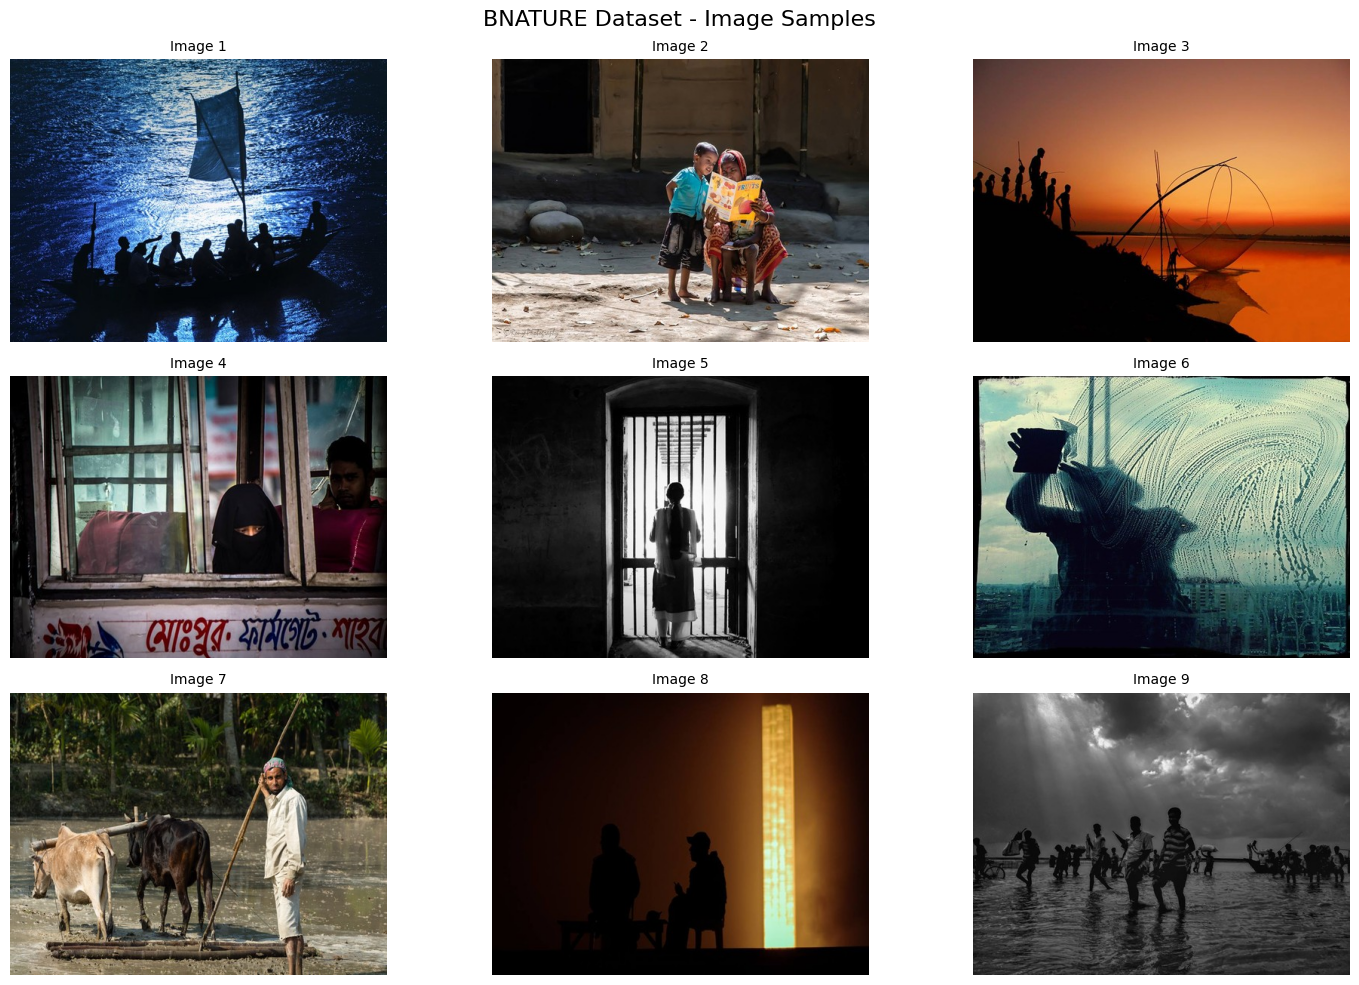

Dataset: Bangla Lekha
Total Entries: 9154
Image Count: 9154
Sample Captions:
  - {'filename': '1.png', 'caption': ['তিন জন মেয়ে মানুষ আছে। এক জন দাড়িয়ে আছে আর দুই জন বসে আছে।', 'একটি হলুদ জামা পায়জামা পরা মহিলা দাড়িয়ে হাতে একটি বেত নিয়ে পিটানোর ভাব দেখাচ্ছে আর ছোট একটি মেয়ে পিছনে ব্যাগ নিয়ে বসে কাঁদছে। ']}
  - {'filename': '2.png', 'caption': ['অনেক মেয়ে মানুষ বসে আছে।', 'একটি নীল জামা পরা মহিলা একটি নীল ল্যাপটপ এর দিকে তাকিয়ে আছে এবং পিছনে  তার দিকে বসে শারি পরে তাকিয়ে আছে অনেকগুলো মহিলা। ']}
  - {'filename': '3.png', 'caption': ['অনেক মানুষ একসাথে বসে কাজ করছে।', '২ টি  ছোট ছেলে একজন শার্ট প্যান্ট  দাড়িয়ে চেয়ে আছে আরেকজন বসে গার্মেন্টস এ কাজ করছে নীল  শার্ট পরে তাদের পিছনে অনেকগুলো মহিলা বসে দাড়িয়ে কাজ করছে।  ']}




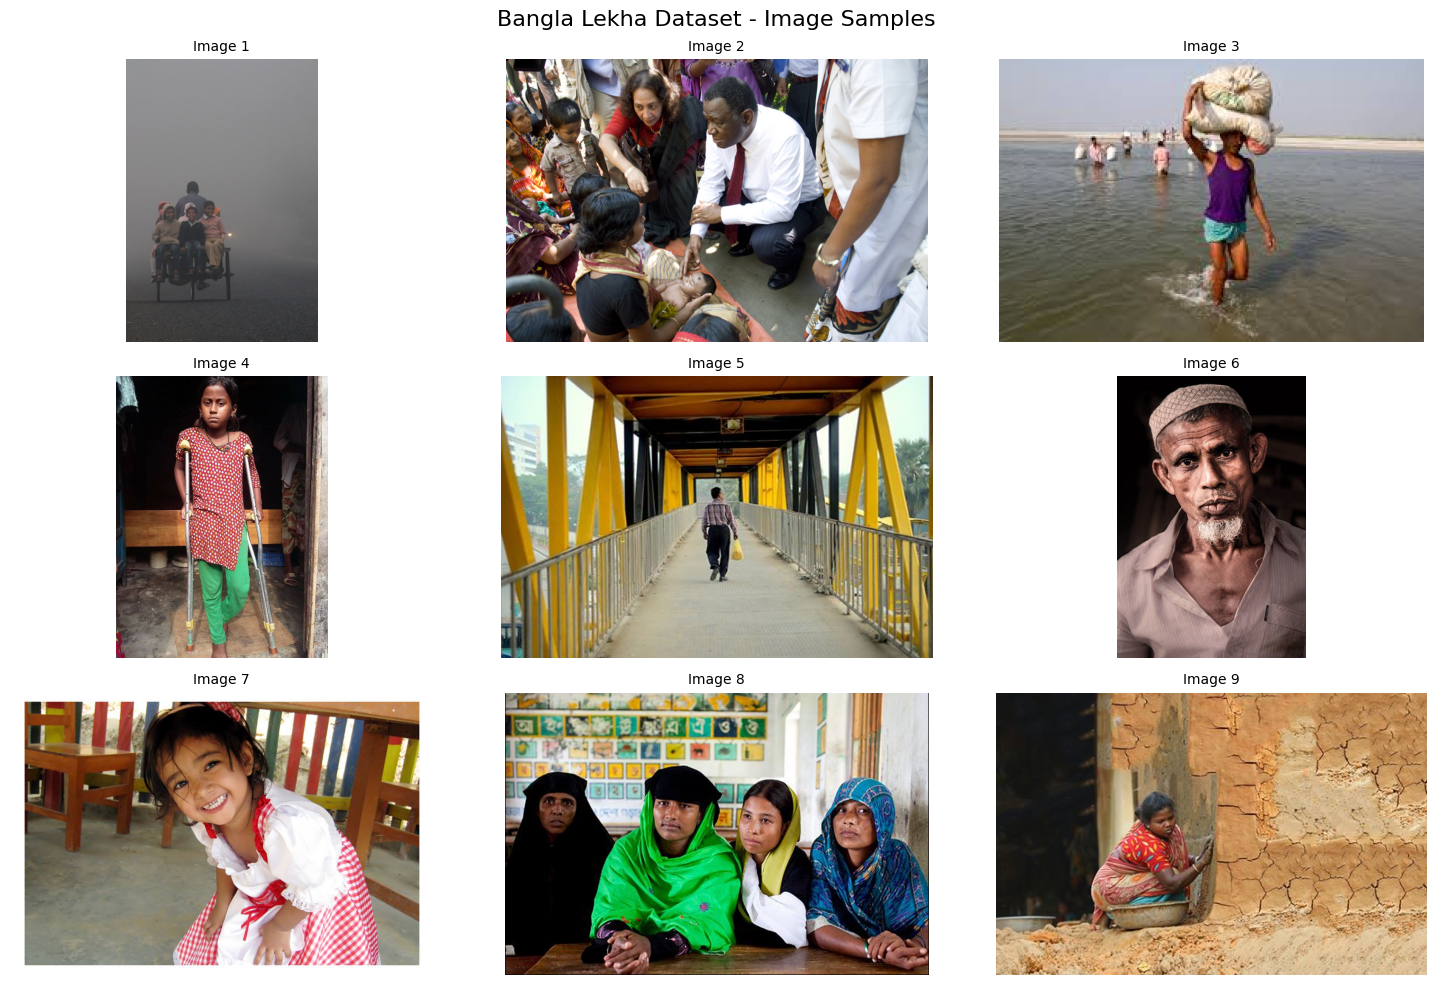

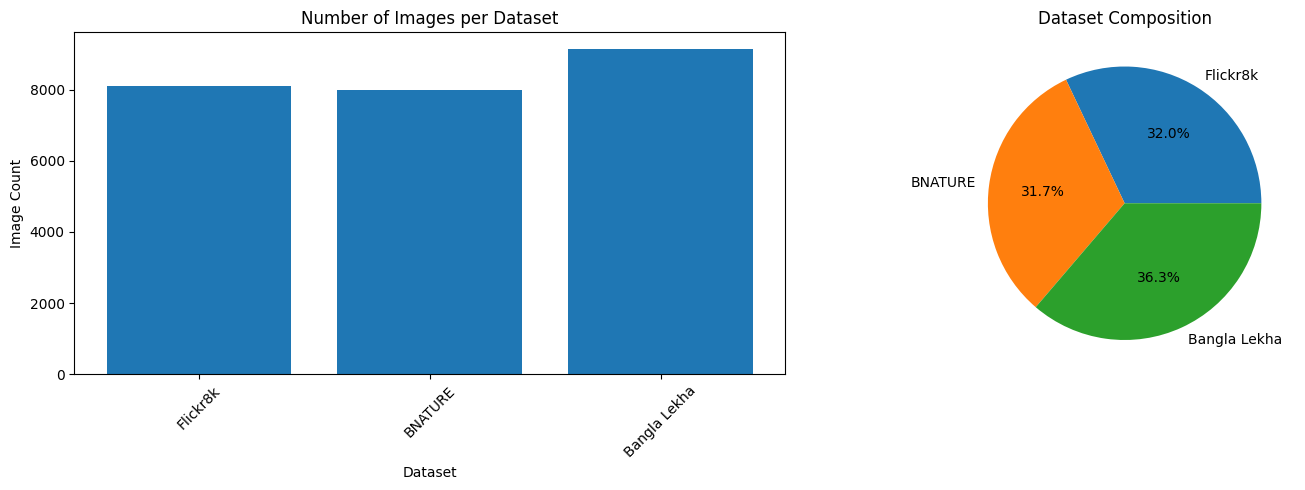

In [21]:
import os
import json
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from PIL import Image
import random

class DatasetAnalyzer:
    def __init__(self, image_path1, captions_path1,
                 image_path2, captions_path2,
                 image_path3, captions_path3):
        self.paths = {
            'Flickr8k': {
                'image_path': image_path1,
                'captions_path': os.path.join(captions_path1, 'BAN-Cap_captiondata.json')
            },
            'BNATURE': {
                'image_path': image_path2,
                'captions_path': captions_path2
            },
            'Bangla Lekha': {
                'image_path': image_path3,
                'captions_path': captions_path3
            }
        }

    def analyze_dataset(self, name, data, image_path):
        # Count total entries and unique images
        total_entries = len(data)

        # Count images
        if os.path.exists(image_path):
            image_files = [f for f in os.listdir(image_path) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
            image_count = len(image_files)
        else:
            image_files = []
            image_count = 0

        # Sample a few captions
        caption_samples = data[:3] if len(data) > 0 else []

        # Randomly select a few images for visualization
        sample_images = random.sample(image_files, min(9, len(image_files))) if image_files else []

        return {
            'name': name,
            'total_entries': total_entries,
            'image_count': image_count,
            'caption_samples': [str(cap) for cap in caption_samples],
            'sample_images': sample_images,
            'image_path': image_path
        }

    def visualize_dataset(self, dataset_info):
        # Create a figure for image grid
        plt.figure(figsize=(15, 10))
        plt.suptitle(f"{dataset_info['name']} Dataset - Image Samples", fontsize=16)

        # Plot image grid
        for i, img_name in enumerate(dataset_info['sample_images'], 1):
            img_path = os.path.join(dataset_info['image_path'], img_name)
            plt.subplot(3, 3, i)
            img = Image.open(img_path)
            plt.imshow(img)
            plt.axis('off')
            plt.title(f"Image {i}", fontsize=10)

        plt.tight_layout()
        plt.show()

    def load_and_analyze(self):
        results = []

        # Datasets to analyze
        dataset_configs = [
            ('Flickr8k', 'captions_path', 'image_path'),
            ('BNATURE', 'captions_path', 'image_path'),
            ('Bangla Lekha', 'captions_path', 'image_path')
        ]

        for name, captions_key, images_key in dataset_configs:
            try:
                # Load captions
                with open(self.paths[name][captions_key], 'r', encoding='utf-8') as f:
                    data = json.load(f)

                # Analyze dataset
                result = self.analyze_dataset(
                    name,
                    data,
                    self.paths[name][images_key]
                )
                results.append(result)

            except Exception as e:
                print(f"Error analyzing {name}: {e}")

        return results

    def comprehensive_visualization(self, results):
        # Create summary visualizations
        plt.figure(figsize=(15, 5))

        # Bar plot of dataset sizes
        plt.subplot(1, 2, 1)
        dataset_names = [result['name'] for result in results]
        image_counts = [result['image_count'] for result in results]

        plt.bar(dataset_names, image_counts)
        plt.title('Number of Images per Dataset')
        plt.xlabel('Dataset')
        plt.ylabel('Image Count')
        plt.xticks(rotation=45)

        # Pie chart of dataset composition
        plt.subplot(1, 2, 2)
        plt.pie(image_counts, labels=dataset_names, autopct='%1.1f%%')
        plt.title('Dataset Composition')

        plt.tight_layout()
        plt.show()

# Example usage
def main():
    # Paths (replace with your actual paths)
    analyzer = DatasetAnalyzer(
        '/content/drive/MyDrive/Bangla Image dataset with caption/Flickr8k_Dataset/Flicker8k_Dataset',
        '/content/drive/MyDrive/Bangla Image dataset with caption/Flickr8k_Dataset',
        '/content/drive/MyDrive/Bangla Image dataset with caption/BNATURE/Pictures',
        '/content/drive/MyDrive/Bangla Image dataset with caption/BNATURE/caption/captions.json',
        '/content/drive/MyDrive/Bangla Image dataset with caption/Bangla Lekha 2.0/images',
        '/content/drive/MyDrive/Bangla Image dataset with caption/Bangla Lekha 2.0/captions.json'
    )

    # Analyze datasets
    results = analyzer.load_and_analyze()

    # Detailed output
    for result in results:
        print(f"Dataset: {result['name']}")
        print(f"Total Entries: {result['total_entries']}")
        print(f"Image Count: {result['image_count']}")
        print("Sample Captions:")
        for sample in result['caption_samples']:
            print(f"  - {sample}")
        print("\n")

        # Visualize images for each dataset
        analyzer.visualize_dataset(result)

    # Comprehensive dataset visualization
    analyzer.comprehensive_visualization(results)

if __name__ == "__main__":
    main()